<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Projetos/Polui%C3%A7%C3%A3o%20na%20China%20-%20Series%20Temporais/Polui%C3%A7%C3%A3o_na_China.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [32]:
df = pd.read_csv("/content/poluicao.csv")
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [33]:
df.shape

(43824, 13)

In [34]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [35]:
df = df.dropna()

In [36]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,0
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [37]:
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0
27,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0
28,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41757 entries, 24 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      41757 non-null  int64  
 1   year    41757 non-null  int64  
 2   month   41757 non-null  int64  
 3   day     41757 non-null  int64  
 4   hour    41757 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    41757 non-null  int64  
 7   TEMP    41757 non-null  float64
 8   PRES    41757 non-null  float64
 9   cbwd    41757 non-null  object 
 10  Iws     41757 non-null  float64
 11  Is      41757 non-null  int64  
 12  Ir      41757 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.5+ MB


In [39]:
df.drop(labels = ["No", "year", "month", "day", "hour", "cbwd"], axis = 1, inplace = True)

In [40]:
df

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
24,129.0,-16,-4.0,1020.0,1.79,0,0
25,148.0,-15,-4.0,1020.0,2.68,0,0
26,159.0,-11,-5.0,1021.0,3.57,0,0
27,181.0,-7,-5.0,1022.0,5.36,1,0
28,138.0,-7,-5.0,1022.0,6.25,2,0
...,...,...,...,...,...,...,...
43819,8.0,-23,-2.0,1034.0,231.97,0,0
43820,10.0,-22,-3.0,1034.0,237.78,0,0
43821,10.0,-22,-3.0,1034.0,242.70,0,0
43822,8.0,-22,-4.0,1034.0,246.72,0,0


In [41]:
base_treinamento = df.iloc[:, 1:7].values
base_treinamento

array([[ -16.  ,   -4.  , 1020.  ,    1.79,    0.  ,    0.  ],
       [ -15.  ,   -4.  , 1020.  ,    2.68,    0.  ,    0.  ],
       [ -11.  ,   -5.  , 1021.  ,    3.57,    0.  ,    0.  ],
       ...,
       [ -22.  ,   -3.  , 1034.  ,  242.7 ,    0.  ,    0.  ],
       [ -22.  ,   -4.  , 1034.  ,  246.72,    0.  ,    0.  ],
       [ -21.  ,   -3.  , 1034.  ,  249.85,    0.  ,    0.  ]])

In [42]:
base_teste = df.iloc[:, 0:1].values
base_teste

array([[129.],
       [148.],
       [159.],
       ...,
       [ 10.],
       [  8.],
       [ 12.]])

In [43]:
normalizador = MinMaxScaler(feature_range=(0,1))
base_treinamento_normalizado = normalizador.fit_transform(base_treinamento)
base_treinamento_normalizado

array([[0.35294118, 0.24590164, 0.52727273, 0.00237151, 0.        ,
        0.        ],
       [0.36764706, 0.24590164, 0.52727273, 0.00394662, 0.        ,
        0.        ],
       [0.42647059, 0.2295082 , 0.54545455, 0.00552173, 0.        ,
        0.        ],
       ...,
       [0.26470588, 0.26229508, 0.78181818, 0.42873071, 0.        ,
        0.        ],
       [0.26470588, 0.24590164, 0.78181818, 0.43584525, 0.        ,
        0.        ],
       [0.27941176, 0.26229508, 0.78181818, 0.44138468, 0.        ,
        0.        ]])

In [44]:
normalizador = MinMaxScaler(feature_range = (0, 1))
base_teste_normalizado = normalizador.fit_transform(base_teste)

In [45]:
X = []
y = []
for i in range(120, base_treinamento_normalizado.shape[0]):
  X.append(base_treinamento_normalizado[i - 120:i, 0])
  y.append(base_teste_normalizado[i, 0])

X, y = np.array(X), np.array(y)

In [46]:
X.shape

(41637, 120)

In [47]:
y.shape

(41637,)

In [52]:
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences = True, input_shape = (X.shape[1], 1)))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.3))

regressor.add(Dense(units = 1, activation = "linear"))

regressor.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 120, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 120, 50)        │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 120, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 120, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 120, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,451 (435.36 KB)

 Trainable params: 111,451 (435.36 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
regressor.compile(optimizer = "rmsprop", loss = "mean_squared_error", metrics = ["mean_absolute_error"])

In [54]:
es = EarlyStopping(monitor = "loss", min_delta = 1e-10, patience = 10, verbose = 1) # 0.00000000001
rlc = ReduceLROnPlateau(monitor = "loss", factor = 0.2, patience = 5, verbose = 1)
mcp = ModelCheckpoint(filepath = "pesos.keras", monitor = "loss", save_best_only = True, verbose = 1)

In [56]:
regressor.fit(X, y, epochs = 10, batch_size = 64, callbacks = [es, rlc, mcp])

Epoch 1/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 0.0088 - mean_absolute_error: 0.0700
Epoch 1: loss improved from inf to 0.00869, saving model to pesos.keras
651/651 ━━━━━━━━━━━━━━━━━━━━ 219s 336ms/step - loss: 0.0088 - mean_absolute_error: 0.0700 - learning_rate: 0.0010
Epoch 2/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - loss: 0.0085 - mean_absolute_error: 0.0676
Epoch 2: loss improved from 0.00869 to 0.00814, saving model to pesos.keras
651/651 ━━━━━━━━━━━━━━━━━━━━ 218s 335ms/step - loss: 0.0085 - mean_absolute_error: 0.0676 - learning_rate: 0.0010
Epoch 3/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - loss: 0.0077 - mean_absolute_error: 0.0634
Epoch 3: loss improved from 0.00814 to 0.00753, saving model to pesos.keras
651/651 ━━━━━━━━━━━━━━━━━━━━ 262s 335ms/step - loss: 0.0077 - mean_absolute_error: 0.0634 - learning_rate: 0.0010
Epoch 4/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 0.0074 - mean_absolute_error: 0.0619
Epoch 4: loss improved from 0.00753 to

In [63]:
previsoes_1 = regressor.predict(X)

1302/1302 ━━━━━━━━━━━━━━━━━━━━ 86s 66ms/step


In [64]:
previsoes = normalizador.inverse_transform(previsoes_1)

In [65]:
previsoes.mean()

np.float32(97.339836)

In [67]:
base_teste.mean()

np.float64(98.61321455085375)

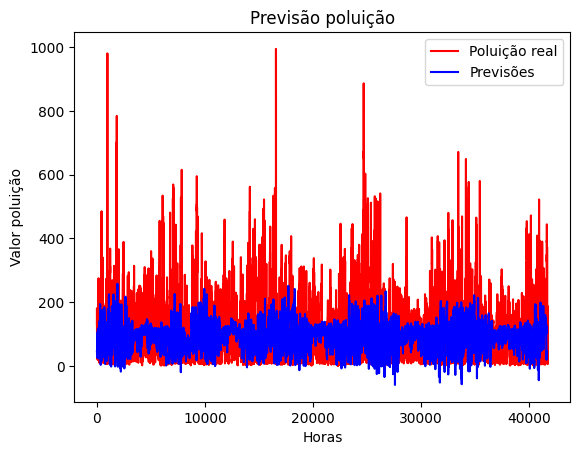

In [73]:
plt.plot(base_teste, color = "red", label = "Poluição real")
plt.plot(previsoes, color = "blue", label = "Previsões")
plt.title("Previsão poluição")
plt.xlabel("Horas")
plt.ylabel("Valor poluição")
plt.legend()
plt.show();